# Análise de Padrão de Consumo

## Bibliotecas

In [767]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



## Extração dos Dados


###BANCO DE DADOS

O conjunto de dados utilizado neste projeto foi obtido através da plataforma Kaggle. A base original pode ser acessada através do link abaixo:

    Fonte Original: [https://www.kaggle.com/datasets/salahuddinahmedshuvo/ecommerce-consumer-behavior-analysis-data]

Todo o banco de dados tratado, foram versionados e estão disponíveis para consulta pública em repositório no GitHub:

    Repositório do Projeto: [https://github.com/PatriciaDuran/hackathon-elas-mais-tech-dados]

In [768]:
# ACESSO POR CSV
url = 'https://raw.githubusercontent.com/PatriciaDuran/hackathon-elas-mais-tech-dados/refs/heads/main/dados/Ecommerce_Consumer_Behavior_Analysis_Data.csv'
df = pd.read_csv(url)

# Confere importação
pd.set_option('display.max_columns', None)
df.head(1)

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,Frequency_of_Purchase,Purchase_Channel,Brand_Loyalty,Product_Rating,Time_Spent_on_Product_Research(hours),Social_Media_Influence,Discount_Sensitivity,Return_Rate,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,4,Mixed,5,5,2.0,NaN,Somewhat Sensitive,1,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2


### Renomeando Colunas

In [769]:
# Renomeando colunas
colunas = {
    'Customer_ID': 'id_cliente',
    'Age': 'idade',
    'Gender': 'genero',
    'Location': 'localizacao',
    'Customer_Loyalty_Program_Member': 'membro_programa_fidelidade',
    'Income_Level': 'faixa_renda',
    'Marital_Status': 'estado_civil',
    'Education_Level': 'nivel_educacao',
    'Occupation': 'ocupacao',
    'Purchase_Category': 'categoria_compra',
    'Product_Rating': 'avaliacao_produto',
    'Purchase_Amount': 'valor_compra',
    'Frequency_of_Purchase': 'frequencia_mensal_compras',
    'Purchase_Channel': 'canal_compra',
    'Payment_Method': 'metodo_pagamento',
    'Time_of_Purchase': 'data_hora_compra',
    'Discount_Used': 'promocao_aplicada',
    'Shipping_Preference': 'preferencia_entrega',

    'Brand_Loyalty': 'nivel_lealdade_marca',
    'Time_Spent_on_Product_Research(hours)': 'tempo_pesquisa_produto',
    'Social_Media_Influence': 'influencia_redes_sociais',
    'Discount_Sensitivity': 'sensibilidade_compra_promocao',
    'Return_Rate': 'taxa_devolucao',
    'Customer_Satisfaction': 'satisfacao_cliente',
    'Engagement_with_Ads': 'interacao_anuncios',
    'Device_Used_for_Shopping': 'dispositivo_compra',
    'Purchase_Intent': 'motivacao_compra',
    'Time_to_Decision': 'dias_decisao_compra'
}

df = df.rename(columns=colunas)

### Renomeando Categorias

In [770]:
# Dicionário de Traduções
traducoes = {

    'genero': {
        'Agender': 'Sem gênero',
        'Bigender': 'Bigênero',
        'Female': 'Feminino',
        'Genderfluid': 'Gênero fluido',
        'Genderqueer': 'Gênero queer',
        'Male': 'Masculino',
        'Non-binary': 'Não-binário',
        'Polygender': 'Poligênero'
    },

    'membro_programa_fidelidade': {
        False: 'Não',
        True: 'Sim'
    },

    'faixa_renda': {
        'High': 'Alta',
        'Middle': 'Média'
    },

    'estado_civil': {
        'Divorced': 'Divorciado',
        'Married': 'Casado',
        'Single': 'Solteiro',
        'Widowed': 'Viúvo'
    },

    'nivel_educacao': {
        "Bachelor's": 'Bacharelado',
        'High School': 'Ensino Médio',
        "Master's": 'Mestrado'
    },

    'ocupacao': {
        'High': 'Alta',
        'Middle': 'Média'
    },

    'categoria_compra': {
        'Animal Feed': 'Ração Animal',
        'Arts & Crafts': 'Artes e Artesanato',
        'Baby Products': 'Produtos para Bebês',
        'Beauty & Personal Care': 'Beleza e Cuidados Pessoais',
        'Books': 'Livros',
        'Clothing': 'Roupas',
        'Electronics': 'Eletrônicos',
        'Food & Beverages': 'Alimentos e Bebidas',
        'Furniture': 'Móveis',
        'Gardening & Outdoors': 'Jardinagem e Área Externa',
        'Groceries': 'Mercado e Mantimentos',
        'Health Care': 'Cuidados com a Saúde',
        'Health Supplements': 'Suplementos de Saúde',
        'Home Appliances': 'Eletrodomésticos',
        'Hotels': 'Hotéis',
        'Jewelry & Accessories': 'Joias e Acessórios',
        'Luxury Goods': 'Produtos de Luxo',
        'Mobile Accessories': 'Acessórios para Celular',
        'Office Supplies': 'Materiais de Escritório',
        'Packages)': 'Pacotes',
        'Software & Apps': 'Softwares e Aplicativos',
        'Sports & Outdoors': 'Esportes e Atividades ao Ar Livre',
        'Toys & Games': 'Brinquedos e Jogos',
        'Travel & Leisure (Flights': 'Viagens e Lazer (Voos'
    },

    'canal_compra': {
        'In-Store': 'Loja Física',
        'Mixed': 'Misto',
        'Online': 'Online'
    },

    'metodo_pagamento': {
        'Cash': 'Dinheiro',
        'Credit Card': 'Cartão de Crédito',
        'Debit Card': 'Cartão de Débito',
        'Other': 'Outro',
        'PayPal': 'PayPal'
    },

    'promocao_aplicada': {
        False: 'Não',
        True: 'Sim'
    },

    'preferencia_entrega': {
        'Express': 'Expresso',
        'No Preference': 'Sem Preferência',
        'Standard': 'Padrão'
    },

    'influencia_redes_sociais': {
        'High': 'Alta',
        'Low': 'Baixa',
        'Medium': 'Média'
    },

    'sensibilidade_compra_promocao': {
        'Not Sensitive': 'Não Sensível',
        'Somewhat Sensitive': 'Moderadamente Sensível',
        'Very Sensitive': 'Muito Sensível'
    },

    'interacao_anuncios': {
        'High': 'Alta',
        'Low': 'Baixa',
        'Medium': 'Média'
    },

    'dispositivo_compra': {
        'Desktop': 'Computador',
        'Smartphone': 'Smartphone',
        'Tablet': 'Tablet'
    },

    'motivacao_compra': {
        'Impulsive': 'Impulsiva',
        'Need-based': 'Baseada em Necessidade',
        'Planned': 'Planejada',
        'Wants-based': 'Baseada em Desejo'
    }
}


In [771]:
# Aplicar traduções
for col, mapa in traducoes.items():
    df[col] = df[col].replace(mapa)

In [772]:
# Conferindo alterações
df.head(5)

,id_cliente,idade,genero,faixa_renda,estado_civil,nivel_educacao,ocupacao,localizacao,categoria_compra,valor_compra,frequencia_mensal_compras,canal_compra,nivel_lealdade_marca,avaliacao_produto,tempo_pesquisa_produto,influencia_redes_sociais,sensibilidade_compra_promocao,taxa_devolucao,satisfacao_cliente,interacao_anuncios,dispositivo_compra,metodo_pagamento,data_hora_compra,promocao_aplicada,membro_programa_fidelidade,motivacao_compra,preferencia_entrega,dias_decisao_compra
0,37-611-6911,22,Feminino,Média,Casado,Bacharelado,Média,Évry,Jardinagem e Área Externa,$333.80,4,Misto,5,5,2.0,NaN,Moderadamente Sensível,1,7,NaN,Tablet,Cartão de Crédito,3/1/2024,Sim,Não,Baseada em Necessidade,Sem Preferência,2
1,29-392-9296,49,Masculino,Alta,Casado,Ensino Médio,Alta,Huocheng,Alimentos e Bebidas,$222.22,11,Loja Física,3,1,2.0,Média,Não Sensível,1,5,Alta,Tablet,PayPal,4/16/2024,Sim,Não,Baseada em Desejo,Padrão,6
2,84-649-5117,24,Feminino,Média,Solteiro,Mestrado,Alta,Huzhen,Materiais de Escritório,$426.22,2,Misto,5,5,0.3,Baixa,Não Sensível,1,7,Baixa,Smartphone,Cartão de Débito,3/15/2024,Sim,Sim,Impulsiva,Sem Preferência,3
3,48-980-6078,29,Feminino,Média,Solteiro,Mestrado,Média,Wiwilí,Eletrodomésticos,$101.31,6,Misto,3,1,1.0,Alta,Moderadamente Sensível,0,1,NaN,Smartphone,Outro,10/4/2024,Sim,Sim,Baseada em Necessidade,Expresso,10
4,91-170-9072,33,Feminino,Média,Viúvo,Ensino Médio,Média,Nara,Móveis,$211.70,6,Misto,3,4,0.0,Média,Não Sensível,2,10,NaN,Smartphone,Cartão de Débito,1/30/2024,Não,Não,Baseada em Desejo,Sem Preferência,4


## Conhecendo o Dataset

### Conhecendo Dados e Estruturas

In [773]:
# Estrutura dos Dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id_cliente                     1000 non-null   object 
 1   idade                          1000 non-null   int64  
 2   genero                         1000 non-null   object 
 3   faixa_renda                    1000 non-null   object 
 4   estado_civil                   1000 non-null   object 
 5   nivel_educacao                 1000 non-null   object 
 6   ocupacao                       1000 non-null   object 
 7   localizacao                    1000 non-null   object 
 8   categoria_compra               1000 non-null   object 
 9   valor_compra                   1000 non-null   object 
 10  frequencia_mensal_compras      1000 non-null   int64  
 11  canal_compra                   1000 non-null   object 
 12  nivel_lealdade_marca           1000 non-null   in

A base para análise possui 1000 registros distribuídos em 28 colunas

Análise inconsistências iniciais:

* Há dados faltantes nas colunas "influencia_redes_sociais" e "interacao_anuncios"
* Coluna "valor_compra" está como tipo object, o que indica haver erroneamente algum caracter
* Coluna "data_hora_compra" está como tipo object em vez de datetime
* Coluna "tempo_pesquisa_produto" está como tipo float, em vez de timedelta64


In [774]:
# Visualizar as primeiras linhas
df.head(5)

,id_cliente,idade,genero,faixa_renda,estado_civil,nivel_educacao,ocupacao,localizacao,categoria_compra,valor_compra,frequencia_mensal_compras,canal_compra,nivel_lealdade_marca,avaliacao_produto,tempo_pesquisa_produto,influencia_redes_sociais,sensibilidade_compra_promocao,taxa_devolucao,satisfacao_cliente,interacao_anuncios,dispositivo_compra,metodo_pagamento,data_hora_compra,promocao_aplicada,membro_programa_fidelidade,motivacao_compra,preferencia_entrega,dias_decisao_compra
0,37-611-6911,22,Feminino,Média,Casado,Bacharelado,Média,Évry,Jardinagem e Área Externa,$333.80,4,Misto,5,5,2.0,NaN,Moderadamente Sensível,1,7,NaN,Tablet,Cartão de Crédito,3/1/2024,Sim,Não,Baseada em Necessidade,Sem Preferência,2
1,29-392-9296,49,Masculino,Alta,Casado,Ensino Médio,Alta,Huocheng,Alimentos e Bebidas,$222.22,11,Loja Física,3,1,2.0,Média,Não Sensível,1,5,Alta,Tablet,PayPal,4/16/2024,Sim,Não,Baseada em Desejo,Padrão,6
2,84-649-5117,24,Feminino,Média,Solteiro,Mestrado,Alta,Huzhen,Materiais de Escritório,$426.22,2,Misto,5,5,0.3,Baixa,Não Sensível,1,7,Baixa,Smartphone,Cartão de Débito,3/15/2024,Sim,Sim,Impulsiva,Sem Preferência,3
3,48-980-6078,29,Feminino,Média,Solteiro,Mestrado,Média,Wiwilí,Eletrodomésticos,$101.31,6,Misto,3,1,1.0,Alta,Moderadamente Sensível,0,1,NaN,Smartphone,Outro,10/4/2024,Sim,Sim,Baseada em Necessidade,Expresso,10
4,91-170-9072,33,Feminino,Média,Viúvo,Ensino Médio,Média,Nara,Móveis,$211.70,6,Misto,3,4,0.0,Média,Não Sensível,2,10,NaN,Smartphone,Cartão de Débito,1/30/2024,Não,Não,Baseada em Desejo,Sem Preferência,4


In [775]:
# visualizar as últimas linhas
df.tail(5)

,id_cliente,idade,genero,faixa_renda,estado_civil,nivel_educacao,ocupacao,localizacao,categoria_compra,valor_compra,frequencia_mensal_compras,canal_compra,nivel_lealdade_marca,avaliacao_produto,tempo_pesquisa_produto,influencia_redes_sociais,sensibilidade_compra_promocao,taxa_devolucao,satisfacao_cliente,interacao_anuncios,dispositivo_compra,metodo_pagamento,data_hora_compra,promocao_aplicada,membro_programa_fidelidade,motivacao_compra,preferencia_entrega,dias_decisao_compra
995,20-562-2569,44,Feminino,Alta,Divorciado,Bacharelado,Alta,Aramayuan,Acessórios para Celular,$463.67,5,Online,2,4,0.30,Alta,Não Sensível,2,4,NaN,Tablet,PayPal,7/7/2024,Sim,Não,Baseada em Necessidade,Padrão,5
996,41-366-4205,50,Feminino,Alta,Solteiro,Ensino Médio,Média,Paquera,Jardinagem e Área Externa,$69.78,9,Misto,4,3,2.00,Baixa,Muito Sensível,0,6,Baixa,Tablet,Dinheiro,3/28/2024,Sim,Não,Baseada em Desejo,Sem Preferência,9
997,77-241-7621,26,Masculino,Alta,Casado,Bacharelado,Alta,Warudoyong,Alimentos e Bebidas,$453.37,10,Misto,1,1,2.00,Baixa,Muito Sensível,0,6,Alta,Computador,Cartão de Crédito,3/11/2024,Sim,Sim,Baseada em Desejo,Expresso,9
998,53-091-2176,21,Feminino,Alta,Viúvo,Bacharelado,Média,Béziers,Produtos para Bebês,$106.15,12,Loja Física,4,4,0.30,Baixa,Moderadamente Sensível,0,5,Média,Computador,Dinheiro,3/30/2024,Sim,Sim,Impulsiva,Padrão,8
999,48-203-9118,21,Feminino,Média,Solteiro,Ensino Médio,Alta,Dongzhou,Cuidados com a Saúde,$378.47,6,Online,5,2,0.33,Média,Não Sensível,1,10,Baixa,Tablet,Outro,12/8/2024,Não,Não,Planejada,Expresso,2


Cada linha apresenta dados sobre o cliente, uma compra do cliente, seu padrão de consumo e satisfação com a experiência.

Análise de necessidades de tranformação dos dados:
* Coluna "valor_compra" está em doláres e inclui o simbolo da moeda. Transformar em float
* Coluna "data_hora_compra" está no formato MM/DD/YYYY. Transformar em padrão brasileiro e em tipo date.
* Columa "tempo_pesquisa_produto" apresenta horas e minutos em formato float, gerando dúvidas em relação a quantidade de minutos. Transformar em tipo timedelta64
* Tratar valores faltantes (NaN) nas colunas "influencia_redes_sociais" e "interacao_anuncios"
* Traduzir colunas categóricas


### Qualidade dos Dados

In [776]:
#Análisede variavéis duplicadas

#Verificar se existem linhas iguais
duplicados_totais = df.duplicated().sum()
print(f"Linhas totalmente duplicadas: {duplicados_totais}")

#Verifica se a coluna id_cliente tem dados duplicados - unicidade
df['id_cliente'].duplicated().sum()

#valor_compra + data_hora_compra -> Para indicar se há transação duplicada
duplicados_transacao = df[df.duplicated(subset=['valor_compra', 'data_hora_compra'], keep=False)]
print(f"Total de registros com valor e hora iguais: {len(duplicados_transacao)}")

Linhas totalmente duplicadas: 0
Total de registros com valor e hora iguais: 0


Motivação das análises:

* Começo verificando se há duplicidade grotesca em que uma linha toda é identica, para retirar caso tenha, o que não foi o caso;

* Se a coluna 'id_cliente' tivesse algum dado duplicado, alteraria na hora do modelo de ML, pois um cliente podia ter mais de um gasto em mais de uma categoria e valor;

* O 'valor_compra' e 'data_hora_compra' (mesmo não alencado para responder a pergunta central) identifica transações duplicadas analisando assim outros fatores para efetivação da resposta.

Porém nenhum deu duplicado, um bom sinal para nosso futuro modelo.

#### Variáveis Categóricas

In [777]:
variaveis_categoricas = [
    'genero',
    'localizacao',
    'membro_programa_fidelidade',
    'faixa_renda',
    'estado_civil',
    'nivel_educacao',
    'ocupacao',
    'categoria_compra',
    'canal_compra',
    'metodo_pagamento',
    'promocao_aplicada',
    'preferencia_entrega',
    'influencia_redes_sociais',
    'sensibilidade_compra_promocao',
    'interacao_anuncios',
    'dispositivo_compra',
    'motivacao_compra'
]

In [778]:
# Análise variáveis categóricas
valores_unicos_categoricas = pd.DataFrame({
        "Coluna": variaveis_categoricas,
        "Qtde categorias": [df[col].nunique() for col in variaveis_categoricas],
        "Valores únicos": [
            ", ".join(sorted(df[col].astype(str).unique()))
            for col in variaveis_categoricas
        ],
        "Frequências": [
            " | ".join(
                f"{k} ({v})" for k, v in df[col].value_counts().items()
            )
            for col in variaveis_categoricas
        ]
    })
valores_unicos_categoricas

,Coluna,Qtde categorias,Valores únicos,Frequências
0,genero,8,"Bigênero, Feminino, Gênero fluido, Gênero quee...",Feminino (452) | Masculino (449) | Bigênero (2...
1,localizacao,969,"Abaetetuba, Abaeté, Abiko, Acheng, Acobambilla...",Oslo (4) | Créteil (3) | Göteborg (3) | Týn na...
2,membro_programa_fidelidade,2,"Não, Sim",Não (509) | Sim (491)
3,faixa_renda,2,"Alta, Média",Alta (515) | Média (485)
4,estado_civil,4,"Casado, Divorciado, Solteiro, Viúvo",Viúvo (260) | Casado (253) | Divorciado (245) ...
5,nivel_educacao,3,"Bacharelado, Ensino Médio, Mestrado",Bacharelado (341) | Ensino Médio (331) | Mestr...
6,ocupacao,2,"Alta, Média",Alta (517) | Média (483)
7,categoria_compra,24,"Acessórios para Celular, Alimentos e Bebidas, ...",Eletrônicos (54) | Esportes e Atividades ao Ar...
8,canal_compra,3,"Loja Física, Misto, Online",Misto (340) | Online (334) | Loja Física (326)
9,metodo_pagamento,5,"Cartão de Crédito, Cartão de Débito, Dinheiro,...",PayPal (219) | Outro (204) | Cartão de Débito ...


Análise de necessidades de tranformação dos dados e pontos a observar:
* 969 localidades diferentes, onde a maior parte das localizações aparecem somente uma vez. Para análise por região seria necessário agrupar regiões
* Não há cliente com faixa de renda baixa, somente média e alta
* A variável "ocupação", que deveria apresentar a profissão do cliente, está apresentando dados incoerentes: Alto e Médio. Essa variavel será desconsiderada para essa análise pois não temos acesso aos dados reais.
* Há 24 diferentes categorias de compra. Para análise seria adequado agrupar categorias para termos uma visão macro e diminuir a dimensionalidade.
* Há valores faltantes nas variáveis "influencia_redes_sociais" e "interacao_anuncios". Como não temos como obter a informação, podemos substituir por "Não informado" para não perdermos as demais informações e podermos analisar outas informações.

Em geral as variáveis categóricas apresentam dados equilibrados, sendo favorável para comparação e previsão de dados e na utilização para criar um modelo de ML.

#### Variáveis Quantitativas

In [779]:
variaveis_quantitativas = [
    'idade',
    'avaliacao_produto',
    'valor_compra',
    'frequencia_mensal_compras',
    'nivel_lealdade_marca',
    'tempo_pesquisa_produto',
    'taxa_devolucao',
    'satisfacao_cliente',
    'dias_decisao_compra'
]

In [780]:
# Análise variáveis quantitativas - se há variáveis numéricas negativas, zeradas ou nulas
resultado = []

for col in variaveis_quantitativas:
    if np.issubdtype(df[col].dtype, np.number):
        resultado.append({
            "coluna": col,
            "negativos": (df[col] < 0).sum(),
            "zerados": (df[col] == 0).sum(),
            "invalidos": df[col].isna().sum()
        })
    else:
        # variável valor_compra - object
        resultado.append({
            "coluna": col,
            "negativos": "N/A (não numérica)",
            "zerados": "N/A",
            "invalidos": df[col].isna().sum()
        })

pd.DataFrame(resultado)

,coluna,negativos,zerados,invalidos
0,idade,0,0,0
1,avaliacao_produto,0,0,0
2,valor_compra,N/A (não numérica),N/A,0
3,frequencia_mensal_compras,0,0,0
4,nivel_lealdade_marca,0,0,0
5,tempo_pesquisa_produto,0,286,0
6,taxa_devolucao,0,352,0
7,satisfacao_cliente,0,0,0
8,dias_decisao_compra,0,0,0


Com exceção da variável "valor_compra", podemos observar que as variáveis quantitativas não apresentam dados inválidos ou negativos.

A variável "taxa_devolução" apresenta valores zerados, porém são valores possíveis para esse caso.

A variável "tempo_pesquisa_produto" apresentam valores zerados. É necessário análise de tratamento do dado, substituindo os valores zerados.  



#### Outras variáveis

In [781]:
# Análise data_hora_compra
# Verifica valores inválidos
pd.to_datetime(df['data_hora_compra'], errors='coerce').isna().sum()


np.int64(0)

Todos os dados apresentam valores válidos para data

## Transformação dos Dados

### Transformação Variáveis Quantitativas

In [782]:
# Dados antes da Transformação
df.head(3)

,id_cliente,idade,genero,faixa_renda,estado_civil,nivel_educacao,ocupacao,localizacao,categoria_compra,valor_compra,frequencia_mensal_compras,canal_compra,nivel_lealdade_marca,avaliacao_produto,tempo_pesquisa_produto,influencia_redes_sociais,sensibilidade_compra_promocao,taxa_devolucao,satisfacao_cliente,interacao_anuncios,dispositivo_compra,metodo_pagamento,data_hora_compra,promocao_aplicada,membro_programa_fidelidade,motivacao_compra,preferencia_entrega,dias_decisao_compra
0,37-611-6911,22,Feminino,Média,Casado,Bacharelado,Média,Évry,Jardinagem e Área Externa,$333.80,4,Misto,5,5,2.0,NaN,Moderadamente Sensível,1,7,NaN,Tablet,Cartão de Crédito,3/1/2024,Sim,Não,Baseada em Necessidade,Sem Preferência,2
1,29-392-9296,49,Masculino,Alta,Casado,Ensino Médio,Alta,Huocheng,Alimentos e Bebidas,$222.22,11,Loja Física,3,1,2.0,Média,Não Sensível,1,5,Alta,Tablet,PayPal,4/16/2024,Sim,Não,Baseada em Desejo,Padrão,6
2,84-649-5117,24,Feminino,Média,Solteiro,Mestrado,Alta,Huzhen,Materiais de Escritório,$426.22,2,Misto,5,5,0.3,Baixa,Não Sensível,1,7,Baixa,Smartphone,Cartão de Débito,3/15/2024,Sim,Sim,Impulsiva,Sem Preferência,3


In [783]:
# Convertendo para float e alterando a formatação da coluna 'valor_compra'
if df['valor_compra'].dtype == 'object':
    df['valor_compra'] = df['valor_compra'].str.replace('$', '').astype(float)

# Análise valor_compra
df['valor_compra'].isna().sum()
df['valor_compra'].describe()

# Convertendo para timedelta64 a coluna 'tempo_pesquisa_produto' sendo o decimal horas
df['tempo_pesquisa_produto'] = pd.to_timedelta(df['tempo_pesquisa_produto'], unit='h') #--não irá ser reconhecido pelo ML

In [784]:
#A variável "tempo_pesquisa_produto" apresentam valores zerados. É necessário análise de tratamento do dado, substituindo os valores zerados.

#Definimos o que é "zero" no formato de tempo
zero_tempo = pd.Timedelta(0)

#Calculando a mediana apenas dos valores maiores que zero_tempo
mediana_tempo = df[df['tempo_pesquisa_produto'] > zero_tempo]['tempo_pesquisa_produto'].median()

#Substituição
df['tempo_pesquisa_produto'] = df['tempo_pesquisa_produto'].replace(zero_tempo, mediana_tempo)

df.head()

,id_cliente,idade,genero,faixa_renda,estado_civil,nivel_educacao,ocupacao,localizacao,categoria_compra,valor_compra,frequencia_mensal_compras,canal_compra,nivel_lealdade_marca,avaliacao_produto,tempo_pesquisa_produto,influencia_redes_sociais,sensibilidade_compra_promocao,taxa_devolucao,satisfacao_cliente,interacao_anuncios,dispositivo_compra,metodo_pagamento,data_hora_compra,promocao_aplicada,membro_programa_fidelidade,motivacao_compra,preferencia_entrega,dias_decisao_compra
0,37-611-6911,22,Feminino,Média,Casado,Bacharelado,Média,Évry,Jardinagem e Área Externa,333.80,4,Misto,5,5,0 days 02:00:00,NaN,Moderadamente Sensível,1,7,NaN,Tablet,Cartão de Crédito,3/1/2024,Sim,Não,Baseada em Necessidade,Sem Preferência,2
1,29-392-9296,49,Masculino,Alta,Casado,Ensino Médio,Alta,Huocheng,Alimentos e Bebidas,222.22,11,Loja Física,3,1,0 days 02:00:00,Média,Não Sensível,1,5,Alta,Tablet,PayPal,4/16/2024,Sim,Não,Baseada em Desejo,Padrão,6
2,84-649-5117,24,Feminino,Média,Solteiro,Mestrado,Alta,Huzhen,Materiais de Escritório,426.22,2,Misto,5,5,0 days 00:18:00,Baixa,Não Sensível,1,7,Baixa,Smartphone,Cartão de Débito,3/15/2024,Sim,Sim,Impulsiva,Sem Preferência,3
3,48-980-6078,29,Feminino,Média,Solteiro,Mestrado,Média,Wiwilí,Eletrodomésticos,101.31,6,Misto,3,1,0 days 01:00:00,Alta,Moderadamente Sensível,0,1,NaN,Smartphone,Outro,10/4/2024,Sim,Sim,Baseada em Necessidade,Expresso,10
4,91-170-9072,33,Feminino,Média,Viúvo,Ensino Médio,Média,Nara,Móveis,211.70,6,Misto,3,4,0 days 01:00:00,Média,Não Sensível,2,10,NaN,Smartphone,Cartão de Débito,1/30/2024,Não,Não,Baseada em Desejo,Sem Preferência,4


- A escolha da mediana ao invés da média foi porque ela ignora os extremos e foca no centro real.

In [785]:
#A variável "tempo_pesquisa_produto" apresentam valores zerados. É necessário análise de tratamento do dado, substituindo os valores zerados.

#Definimos o que é "zero" no formato de tempo
zero_tempo = pd.Timedelta(0)

#Calculando a mediana apenas dos valores maiores que zero_tempo
mediana_tempo = df[df['tempo_pesquisa_produto'] > zero_tempo]['tempo_pesquisa_produto'].median()

#Substituição
df['tempo_pesquisa_produto'] = df['tempo_pesquisa_produto'].replace(zero_tempo, mediana_tempo)

df.head()

,id_cliente,idade,genero,faixa_renda,estado_civil,nivel_educacao,ocupacao,localizacao,categoria_compra,valor_compra,frequencia_mensal_compras,canal_compra,nivel_lealdade_marca,avaliacao_produto,tempo_pesquisa_produto,influencia_redes_sociais,sensibilidade_compra_promocao,taxa_devolucao,satisfacao_cliente,interacao_anuncios,dispositivo_compra,metodo_pagamento,data_hora_compra,promocao_aplicada,membro_programa_fidelidade,motivacao_compra,preferencia_entrega,dias_decisao_compra
0,37-611-6911,22,Feminino,Média,Casado,Bacharelado,Média,Évry,Jardinagem e Área Externa,333.80,4,Misto,5,5,0 days 02:00:00,NaN,Moderadamente Sensível,1,7,NaN,Tablet,Cartão de Crédito,3/1/2024,Sim,Não,Baseada em Necessidade,Sem Preferência,2
1,29-392-9296,49,Masculino,Alta,Casado,Ensino Médio,Alta,Huocheng,Alimentos e Bebidas,222.22,11,Loja Física,3,1,0 days 02:00:00,Média,Não Sensível,1,5,Alta,Tablet,PayPal,4/16/2024,Sim,Não,Baseada em Desejo,Padrão,6
2,84-649-5117,24,Feminino,Média,Solteiro,Mestrado,Alta,Huzhen,Materiais de Escritório,426.22,2,Misto,5,5,0 days 00:18:00,Baixa,Não Sensível,1,7,Baixa,Smartphone,Cartão de Débito,3/15/2024,Sim,Sim,Impulsiva,Sem Preferência,3
3,48-980-6078,29,Feminino,Média,Solteiro,Mestrado,Média,Wiwilí,Eletrodomésticos,101.31,6,Misto,3,1,0 days 01:00:00,Alta,Moderadamente Sensível,0,1,NaN,Smartphone,Outro,10/4/2024,Sim,Sim,Baseada em Necessidade,Expresso,10
4,91-170-9072,33,Feminino,Média,Viúvo,Ensino Médio,Média,Nara,Móveis,211.70,6,Misto,3,4,0 days 01:00:00,Média,Não Sensível,2,10,NaN,Smartphone,Cartão de Débito,1/30/2024,Não,Não,Baseada em Desejo,Sem Preferência,4


- A escolha da mediana ao invés da média foi porque ela ignora os extremos e foca no centro real.

O primeiro desafio identificado foi na coluna valor_compra. Os dados chegaram em formato de texto (object) devido ao símbolo de moeda. Para que o sistema pudesse realizar operações estatísticas, executei o tratamento de string e a conversão para float. Sem essa higienização, qualquer tentativa de soma ou média resultaria em erro de execução ou inconsistência lógica;

Ao analisar a variável tempo_pesquisa_produto, me deparei com a presença de valores zerados. Em um cenário de comportamento do consumidor, um "zero" absoluto em tempo de pesquisa muitas vezes não representa a realidade, mas sim uma falha na captura do dado ou uma inconsistência;

```
Em vez de simplesmente descartar esses registros, optei por uma técnica de imputação de dados.

Por que a Mediana? Como destaquei no código, a escolha da mediana sobre a média foi estratégica. A média é facilmente distorcida por valores extremos (outliers). A mediana nos fornece o "centro real" da distribuição.

Aplicação Seletiva: O cálculo da mediana foi realizado considerando apenas os valores maiores que zero, garantindo que a nova métrica aplicada fosse fiel aos usuários que de fato registraram seu tempo de interação.
```



### Transformação Variáveis Categóricas

In [786]:
#Tratando colunas vazias com 'Nan'

valores_para_preencher = {
    'influencia_redes_sociais': 'None informed',
    'interacao_anuncios': 'None informed'
}

df.fillna(value=valores_para_preencher, inplace=True)

# Verificação de nulos novamente
print(df[['influencia_redes_sociais', 'interacao_anuncios']].isna().sum())



influencia_redes_sociais    0
interacao_anuncios          0
dtype: int64


In [787]:
# Conferindo dados após transformações
df.head(3)

,id_cliente,idade,genero,faixa_renda,estado_civil,nivel_educacao,ocupacao,localizacao,categoria_compra,valor_compra,frequencia_mensal_compras,canal_compra,nivel_lealdade_marca,avaliacao_produto,tempo_pesquisa_produto,influencia_redes_sociais,sensibilidade_compra_promocao,taxa_devolucao,satisfacao_cliente,interacao_anuncios,dispositivo_compra,metodo_pagamento,data_hora_compra,promocao_aplicada,membro_programa_fidelidade,motivacao_compra,preferencia_entrega,dias_decisao_compra
0,37-611-6911,22,Feminino,Média,Casado,Bacharelado,Média,Évry,Jardinagem e Área Externa,333.80,4,Misto,5,5,0 days 02:00:00,None informed,Moderadamente Sensível,1,7,None informed,Tablet,Cartão de Crédito,3/1/2024,Sim,Não,Baseada em Necessidade,Sem Preferência,2
1,29-392-9296,49,Masculino,Alta,Casado,Ensino Médio,Alta,Huocheng,Alimentos e Bebidas,222.22,11,Loja Física,3,1,0 days 02:00:00,Média,Não Sensível,1,5,Alta,Tablet,PayPal,4/16/2024,Sim,Não,Baseada em Desejo,Padrão,6
2,84-649-5117,24,Feminino,Média,Solteiro,Mestrado,Alta,Huzhen,Materiais de Escritório,426.22,2,Misto,5,5,0 days 00:18:00,Baixa,Não Sensível,1,7,Baixa,Smartphone,Cartão de Débito,3/15/2024,Sim,Sim,Impulsiva,Sem Preferência,3


### Outras Variáveis

In [788]:
# Convertendo 'id_cliente' para String
df['id_cliente'] = df['id_cliente'].astype(str)

# Convertendo para date e alterando a formatação da coluna 'data_hora_compra'
df['data_hora_compra'] = pd.to_datetime(df['data_hora_compra'], format = '%m/%d/%Y')

## Feature Engineering

### Feature Engineering - Variável categoria_compra

In [789]:
# categorias antes
df['categoria_compra'].value_counts()

,count
categoria_compra,
Eletrônicos,54
Esportes e Atividades ao Ar Livre,51
Joias e Acessórios,50
Eletrodomésticos,50
Brinquedos e Jogos,47
Ração Animal,44
Alimentos e Bebidas,44
Jardinagem e Área Externa,44
Pacotes,43


In [790]:
mapa_categorias = {

    "Eletrônicos": "Tech & Digital",
    "Acessórios para Celular": "Tech & Digital",
    "Softwares e Aplicativos": "Tech & Digital",

    "Eletrodomésticos": "Casa & Lar",
    "Móveis": "Casa & Lar",
    "Jardinagem e Área Externa": "Casa & Lar",
    "Materiais de Escritório": "Casa & Lar",
    "Artes e Artesanato": "Casa & Lar",

    "Alimentos e Bebidas": "Consumo Essencial",
    "Mercado e Mantimentos": "Consumo Essencial",
    "Produtos para Bebês": "Consumo Essencial",
    "Ração Animal": "Consumo Essencial",

    "Suplementos de Saúde": "Saúde & Bem-estar",
    "Cuidados com a Saúde": "Saúde & Bem-estar",
    "Beleza e Cuidados Pessoais": "Saúde & Bem-estar",
    "Esportes e Atividades ao Ar Livre": "Saúde & Bem-estar",

    "Viagens e Lazer (Voos": "Lifestyle & Lazer",
    "Hotéis": "Lifestyle & Lazer",
    "Brinquedos e Jogos": "Lifestyle & Lazer",
    "Livros": "Lifestyle & Lazer",
    "Joias e Acessórios": "Lifestyle & Lazer",
    "Produtos de Luxo": "Lifestyle & Lazer",

    "Roupas": "Vestuário",
    "Pacotes": "Vestuário"
}

df["grupo_categoria_compra"] = df["categoria_compra"].map(mapa_categorias)

In [791]:
df['grupo_categoria_compra'].value_counts()

,count
grupo_categoria_compra,
Lifestyle & Lazer,245
Casa & Lar,207
Consumo Essencial,170
Saúde & Bem-estar,167
Tech & Digital,138
Vestuário,73


Feature Engineering - Variável idade

In [792]:
df['idade'].describe()

,idade
count,1000.000000
mean,34.304000
std,9.353238
min,18.000000
25%,26.000000
50%,34.500000
75%,42.000000
max,50.000000


Clientes de idade entre 18 e 50 anos

In [793]:
df[["idade", "valor_compra"]].corr()

,idade,valor_compra
idade,1.0000,-0.0163
valor_compra,-0.0163,1.0000


A variável idade apresentou correlação próxima de zero (-0.016) com o valor de compra, indicando ausência de relação linear.

Por esse motivo, será criada uma variável que representa a faixa etária da idade, permitindo analisar possíveis relações não lineares entre a idade e o comportamento de consumo.

In [794]:
# bins sem sobreposição
bins = [18, 25, 36, 46, 51]

# labels das faixas etárias
labels = ['18 a 24', '25 a 35', '36 a 45', '46 a 50']

df['faixa_etaria'] = pd.cut(
    df['idade'],
    bins=bins,
    labels=labels,
    right=False
)

Segmentação por Faixa Etária

Conforme análise descritiva, a base de dados contempla clientes entre 18 e 50 anos. Para reduzir a dimensionalidade da variável idade, os clientes foram segmentados em 4 faixas etárias, que representam fases distintas da vida adulta:

| Faixa Etária | Fase da Vida   |
|--------------|----------------|
| 18 a 24      | Jovem          |
| 25 a 35      | Jovem Adulto   |
| 36 a 45      | Adulto         |
| 46 a 50      | Adulto Maduro  |

In [795]:
# validando nova coluna
df[['idade', 'faixa_etaria']].head()

,idade,faixa_etaria
0,22,18 a 24
1,49,46 a 50
2,24,18 a 24
3,29,25 a 35
4,33,25 a 35


In [796]:
# quantos registros por faixa_etaria
df['faixa_etaria'].value_counts().sort_index()

,count
faixa_etaria,
18 a 24,190
25 a 35,340
36 a 45,320
46 a 50,150


###Feature Engineering - Variável gênero

In [797]:
#Contagem e Percentual
contagem = df['genero'].value_counts()
percentual = df['genero'].value_counts(normalize=True) * 100

#Resumo dos dados
resumo_genero = pd.DataFrame({'Qtd': contagem, 'Percentual(%)': percentual})
print(resumo_genero)

#Limite de corte
limite = 10
categorias_baixas = percentual[percentual < limite].index

#Substituindo por 'Outros'
df['genero_agrupado'] = df['genero'].replace(categorias_baixas, 'Outros')
print(df['genero_agrupado'].value_counts(normalize=True) * 100)

               Qtd  Percentual(%)
genero                           
Feminino       452           45.2
Masculino      449           44.9
Bigênero        20            2.0
Sem gênero      19            1.9
Gênero fluido   17            1.7
Não-binário     16            1.6
Poligênero      15            1.5
Gênero queer    12            1.2
genero_agrupado
Feminino     45.2
Masculino    44.9
Outros        9.9
Name: proportion, dtype: float64


A coluna categorica 'genero' possui 8 atributos, os quais eu precisei analisar para entender o percentual de cada um, e foi visto que possui 6 atinutos com o percentual menor que 10% de quantidade total da coluna, fazendo com que eu otimizasse para 3 atributos, com os dois principais e um englobando os que baixos percentuais.

| genero_agrupado | Percentual   |
|--------------|----------------|
| Feminino      | 45.2%          |
| Musculino      | 44.9%   |
| Outros      | 9.9%         |

In [798]:
limite = 10
percentual = df['genero'].value_counts(normalize=True) * 100
categorias_manter = percentual[percentual >= limite].index

df['genero_agrupado'] = np.where(
    df['genero'].isin(categorias_manter),
    df['genero'],
    'Outros'
)

In [799]:
df[['genero_agrupado']].head()

,genero_agrupado
0,Feminino
1,Masculino
2,Feminino
3,Feminino
4,Feminino


###Feature Engineering - Variável Canal de Compra

In [800]:
limite = 10
percentual_canal = df['canal_compra'].value_counts(normalize=True) * 100
canais_manter = percentual_canal[percentual_canal >= limite].index

#criando a coluna agrupada
df['canal_agrupado'] = np.where(
    df['canal_compra'].isin(canais_manter),
    df['canal_compra'],
    'Outros'
)

print(df['canal_agrupado'].value_counts(normalize=True) * 100)

canal_agrupado
Misto          34.0
Online         33.4
Loja Física    32.6
Name: proportion, dtype: float64


## Análise Exploratória

### Análise Descritiva

In [801]:
df.describe()

,idade,valor_compra,frequencia_mensal_compras,nivel_lealdade_marca,avaliacao_produto,tempo_pesquisa_produto,taxa_devolucao,satisfacao_cliente,data_hora_compra,dias_decisao_compra
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000,1000.000000
mean,34.304000,275.063880,6.945000,3.026000,3.033000,0 days 01:17:56.508000,0.954000,5.399000,2024-06-29 06:31:40.800000,7.547000
min,18.000000,50.710000,2.000000,1.000000,1.000000,0 days 00:12:00,0.000000,1.000000,2024-01-01 00:00:00,1.000000
25%,26.000000,162.235000,4.000000,2.000000,2.000000,0 days 01:00:00,0.000000,3.000000,2024-04-04 00:00:00,4.000000
50%,34.500000,276.165000,7.000000,3.000000,3.000000,0 days 01:00:00,1.000000,5.000000,2024-06-30 00:00:00,8.000000
75%,42.000000,388.982500,10.000000,4.000000,4.000000,0 days 02:00:00,2.000000,8.000000,2024-09-19 00:00:00,11.000000
max,50.000000,498.330000,12.000000,5.000000,5.000000,0 days 02:00:00,2.000000,10.000000,2024-12-30 00:00:00,14.000000
std,9.353238,131.532998,3.147361,1.416803,1.436654,0 days 00:30:04.768311610,0.810272,2.868454,NaN,4.035849



- Análise dos quartis (25%, 50%, 75%) mostra que o conjunto de dados é relativamente simétrico, onde a média (mean) e a mediana (50%) possuem valores muito próximos na maioria das colunas;

#### A faixa etária influência no valor da compra ?

In [802]:
df.groupby('faixa_etaria')['valor_compra'].agg(['mean','median','std','count'])

/tmp/ipykernel_4135/2886888235.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('faixa_etaria')['valor_compra'].agg(['mean','median','std','count'])


,mean,median,std,count
faixa_etaria,,,,
18 a 24,282.128895,274.055,126.288086,190
25 a 35,276.357412,277.145,133.339311,340
36 a 45,274.919375,285.440,130.351912,320
46 a 50,263.491133,259.410,136.879051,150


/tmp/ipykernel_4135/1739504592.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


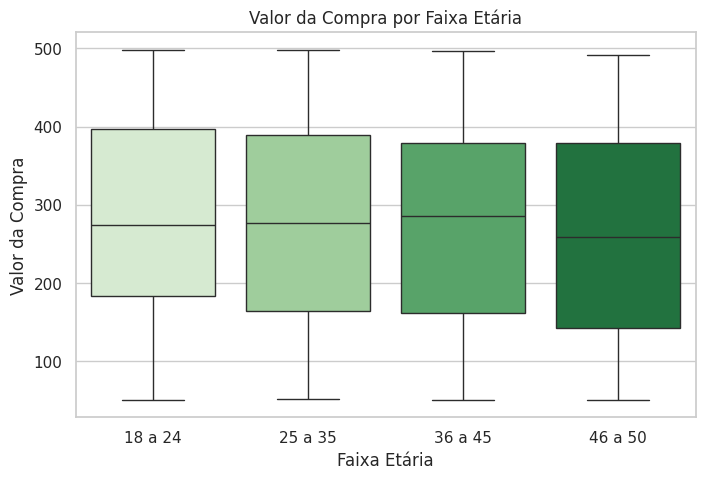

In [803]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='faixa_etaria',
    y='valor_compra',
    palette='Greens'
)

plt.title('Valor da Compra por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Valor da Compra')

plt.show()

Os jovens de 18 a 24 anos apresentam compras que chegam a valores mais altos, próximos de 400 dólares, mas esse comportamento também aparece nas outras faixas etárias.

Os clientes de 46 a 50 anos tendem a ter valores um pouco menores, mas ainda dentro de uma faixa bem parecida com os demais.

Não há presença de outliers, e os valores de compra, independentemente da faixa etária, ficam aproximadamente entre 150 e 400 dólares.

As faixas etárias apresentam medianas muito semelhantes, com uma leve vantagem para a faixa de 36 a 45 anos, e os valores de compra são bastante parecidos entre os grupos. No geral, isso indica que a faixa etária não tem uma influência forte no valor da compra.



/tmp/ipykernel_4135/3069678087.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


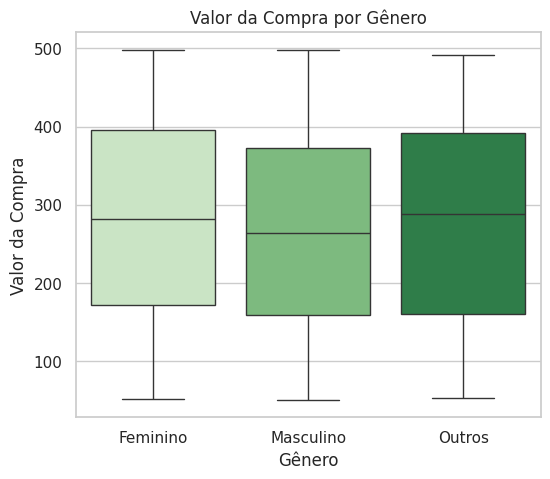

In [804]:
# análise genero x valor_compra
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x='genero_agrupado',
    y='valor_compra',
    palette='Greens'
)

plt.title('Valor da Compra por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Valor da Compra')

plt.show()

De forma geral, os valores de compra são bastante parecidos entre os gêneros, sem uma diferença muito expressiva entre os grupos.

O grupo Outros apresenta uma mediana ligeiramente maior em relação aos demais, enquanto o grupo Masculino apresenta uma mediana um pouco menor.

O grupo Feminino fica em um nível intermediário, com valores próximos aos outros grupos.

Além disso, todos os gêneros apresentam uma variação semelhante nos valores de compra, com distribuições bastante parecidas.

No geral, o gênero isoladamente não apresenta uma influência forte no valor da compra, já que os comportamentos entre os grupos são bastante similares.

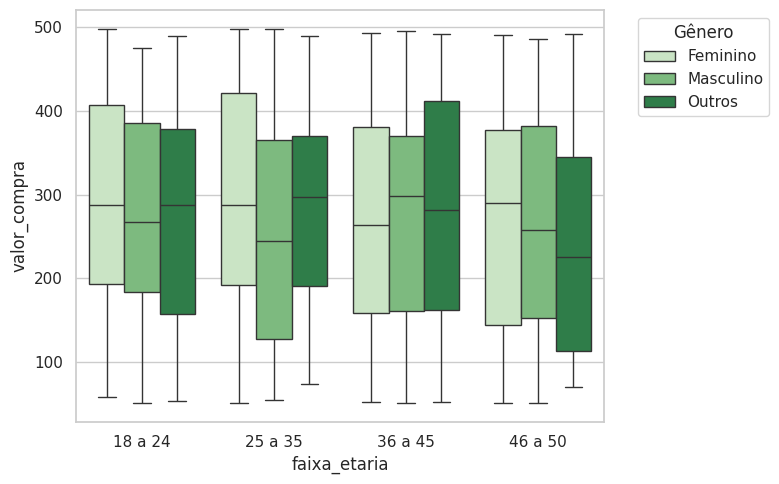

In [805]:
# análise faixa_etaria x genero x valor_compra
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='faixa_etaria',
    y='valor_compra',
    hue='genero_agrupado',
    palette='Greens'
)

plt.legend(title='Gênero', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

As medianas continuam bem próximas entre as faixas etárias, mesmo considerando o gênero, o que indica que a idade, sozinha, não tem uma influência forte no valor da compra.

Ao analisar por gênero, dá pra notar que o grupo feminino tende a apresentar valores um pouco mais altos em algumas faixas etárias, principalmente entre 18 a 24 e 25 a 35 anos.

O grupo masculino apresenta uma variação maior em algumas faixas, com valores mais espalhados, especialmente entre 25 a 35 anos.

Já o grupo outros mostra um comportamento mais irregular entre as faixas etárias, com destaque para 36 a 45 anos, onde os valores tendem a ser mais altos, mas também com bastante variação.

No geral, os valores de compra são bastante parecidos entre os grupos, tanto considerando a faixa etária quanto o gênero.

Conclusão: apesar da faixa etária e o gênero isoladamente não apresentarem uma influência forte, quando analisados em conjunto é possível observar algumas diferenças no comportamento de compra entre os grupos.

#### A sensibilidade em relação a promoção tem relação com a motivação de compra?

Será que a pessoa sensível a promoções compra por impulso ?


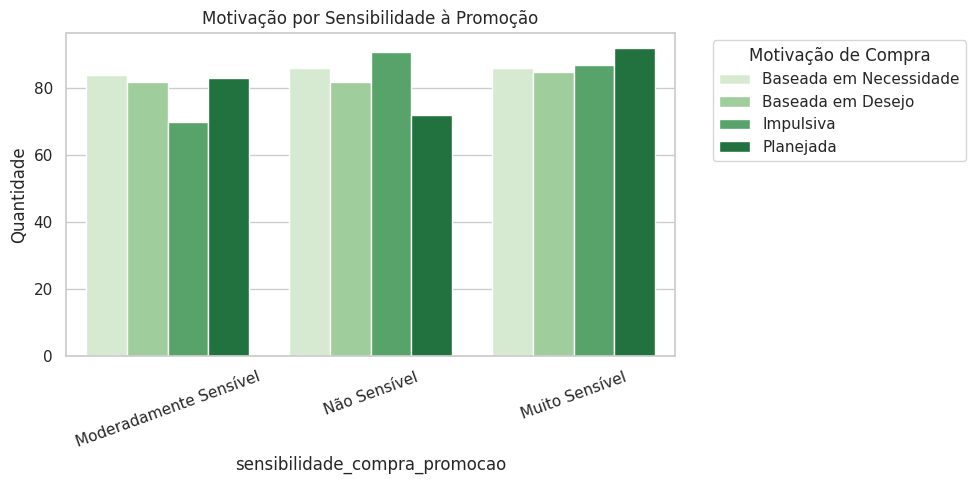

In [806]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='sensibilidade_compra_promocao',
    hue='motivacao_compra',
    palette='Greens'
)

plt.title('Motivação por Sensibilidade à Promoção')
plt.xticks(rotation=20)
plt.ylabel('Quantidade')

plt.legend(title='Motivação de Compra', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

A distribuição entre os grupos é equilibrada, com volumes entre 70 e 91 registros por combinação. Isso indica que a base não tem um perfil dominante de consumido.

No grupo Não Sensível a Promoções as compras impulsivas atingem o maior volume, enquanto as compras planejadas caem para o menor valor. Isso quer dizer que quem não liga para desconto tende a decidir na hora, sem planejamento e sem esperar por uma oferta.

O oposto aparece no grupo Muito Sensível, onde as compras planejadas predominam. Esse consumidor pesquisa, aguarda a promoção e só então compra. A decisão é racional e calculada.

O grupo Moderadamente Sensível tem o menor número de compras impulsivas, sugerindo, sugerindo que esse perfil de consumidor é o mais contido na hora de comprar.

#### O gênero e a categoria influenciam no valor da compra?

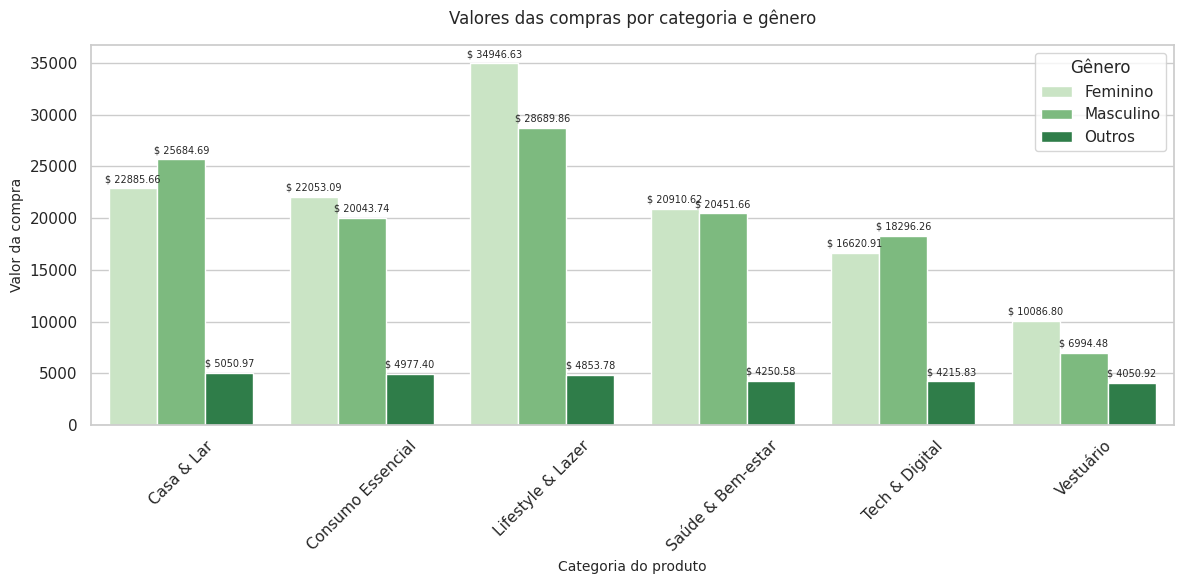

In [807]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df,
    x='grupo_categoria_compra',
    y='valor_compra',
    hue='genero_agrupado',
    estimator='sum',
    errorbar=None,
    palette='Greens'
)

plt.title('Valores das compras por categoria e gênero', fontsize=12, pad=15)
plt.xlabel('Categoria do produto', fontsize=10)
plt.ylabel('Valor da compra', fontsize=10)
plt.legend(title='Gênero')

for container in ax.containers:
    ax.bar_label(container, fmt='$ %.2f', padding=3, fontsize=7)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A análise entre Gênero, Categoria e Valor Total de Compra revela que ambas as variáveis otem uma influência significativa no faturamento.
Observa-se que o público feminino concentra seu maior volume de gastos em 'Lifestyle & Lazer', enquanto o público masculino apresenta maior engajamento financeiro em produtos de 'Tech & Digital' e 'Casa & Lar'.

E o motivo disso está diretamente relacionado com sócio-politicas, entre outras coisas multifacetadas da sociedade.

####Por meio de qual canal de compra há mais venda e em quais categorias o canal de compra tem o maior valor ?

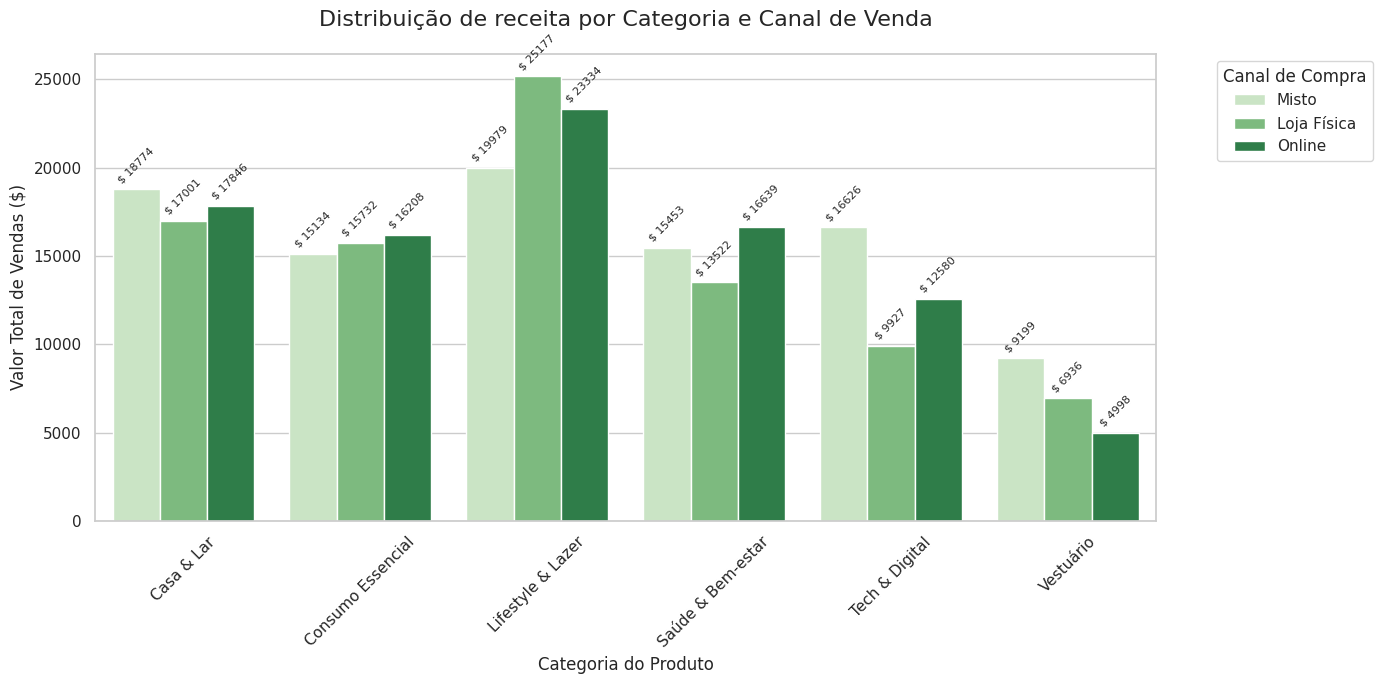

In [808]:
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df,
    x='grupo_categoria_compra',
    y='valor_compra',
    hue='canal_agrupado',
    estimator='sum',
    errorbar=None,
    palette='Greens'
)

plt.title('Distribuição de receita por Categoria e Canal de Venda', fontsize=16, pad=20)
plt.xlabel('Categoria do Produto', fontsize=12)
plt.ylabel('Valor Total de Vendas ($)', fontsize=12)
plt.legend(title='Canal de Compra', bbox_to_anchor=(1.05, 1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fmt='$ %.0f', padding=3, fontsize=8, rotation=45)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A distribuição da receita revela uma predominância do canal de Loja Física em categorias de alto valor agregado e experiência, como 'Lifestyle & Lazer'.
Em contrapartida, observa-se uma migração clara para o canal Online e Misto em categorias funcionais, como 'Saúde & Bem-estar' e 'Tech & Digital'.

Um ponto de estratégica é a categoria 'Vestuário', onde o canal Misto supera o Online puro. Isso indica que estratégias como omnichannel (comprar online e retirar na loja) podem ser o principal motor de vendas para este **segmento**.

#### outras

In [809]:
#Verificando a Assimetria do Valor de Compra
# Se for > 0, significa que temos poucos clientes gastando MUITO
print(f"\nAssimetria da coluna valor_compra: {df['valor_compra'].skew():.2f}")


Assimetria da coluna valor_compra: -0.01


In [810]:
# Pergunta: Quem gasta mais -> Alta Renda ou Média Renda?

analise_renda = df.groupby('faixa_renda')['valor_compra'].agg(['mean', 'median', 'std'])
print(analise_renda)

                   mean  median         std
faixa_renda                                
Alta         275.511631  277.52  131.103311
Média        274.588433  276.08  132.121467


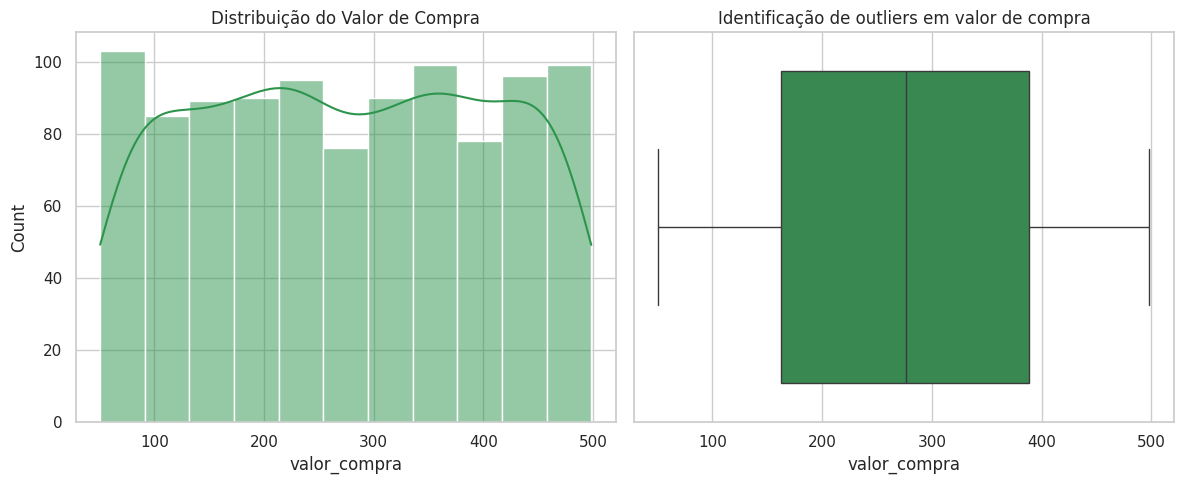

In [811]:
#Configuração visual
plt.figure(figsize=(12, 5))

#Histograma do Valor de Compra
plt.subplot(1, 2, 1)
sns.histplot(df['valor_compra'], kde=True, color=sns.color_palette("Greens")[4])
plt.title('Distribuição do Valor de Compra')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['valor_compra'], color=sns.color_palette("Greens")[4])
plt.title('Identificação de outliers em valor de compra')

plt.tight_layout()
plt.show()

--- Ticket Médio por renda e educação ---
nivel_educacao  Bacharelado  Ensino Médio    Mestrado
faixa_renda                                          
Alta             280.979157    274.637314  270.448580
Média            286.943742    273.731218  263.261988


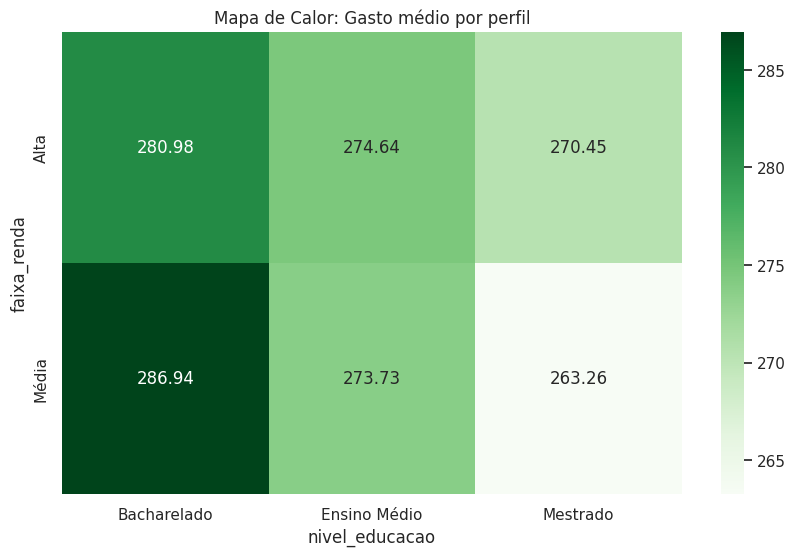

In [812]:
# Agrupando para ver o gasto médio por perfil socioeconômico
perfil_gastos = df.groupby(['faixa_renda', 'nivel_educacao'])['valor_compra'].mean().unstack()

print("--- Ticket Médio por renda e educação ---")
print(perfil_gastos)

# Visualização do mapa de calor
plt.figure(figsize=(10, 6))
sns.heatmap(perfil_gastos, annot=True, fmt=".2f", cmap="Greens")
plt.title('Mapa de Calor: Gasto médio por perfil')
plt.show()

In [813]:
#Analisando se a localização simplificada influencia no gasto
print(df.groupby('localizacao')['valor_compra'].mean().sort_values(ascending=False))

localizacao
Malasin          498.33
Longotea         498.23
Tanahmerah       497.80
Wādī as Salqā    497.76
Nanqiao          497.75
                  ...  
Likhoy            51.44
Norrköping        51.22
Xudat             50.79
Yishui            50.78
Alung             50.71
Name: valor_compra, Length: 969, dtype: float64


## Preparação dos Dados

###Feature Selection

In [814]:
# Removendo colunas desnecessárias
df = df.drop(columns=['id_cliente'])
df.head(1)

,idade,genero,faixa_renda,estado_civil,nivel_educacao,ocupacao,localizacao,categoria_compra,valor_compra,frequencia_mensal_compras,canal_compra,nivel_lealdade_marca,avaliacao_produto,tempo_pesquisa_produto,influencia_redes_sociais,sensibilidade_compra_promocao,taxa_devolucao,satisfacao_cliente,interacao_anuncios,dispositivo_compra,metodo_pagamento,data_hora_compra,promocao_aplicada,membro_programa_fidelidade,motivacao_compra,preferencia_entrega,dias_decisao_compra,grupo_categoria_compra,faixa_etaria,genero_agrupado,canal_agrupado
0,22,Feminino,Média,Casado,Bacharelado,Média,Évry,Jardinagem e Área Externa,333.8,4,Misto,5,5,0 days 02:00:00,None informed,Moderadamente Sensível,1,7,None informed,Tablet,Cartão de Crédito,2024-03-01,Sim,Não,Baseada em Necessidade,Sem Preferência,2,Casa & Lar,18 a 24,Feminino,Misto


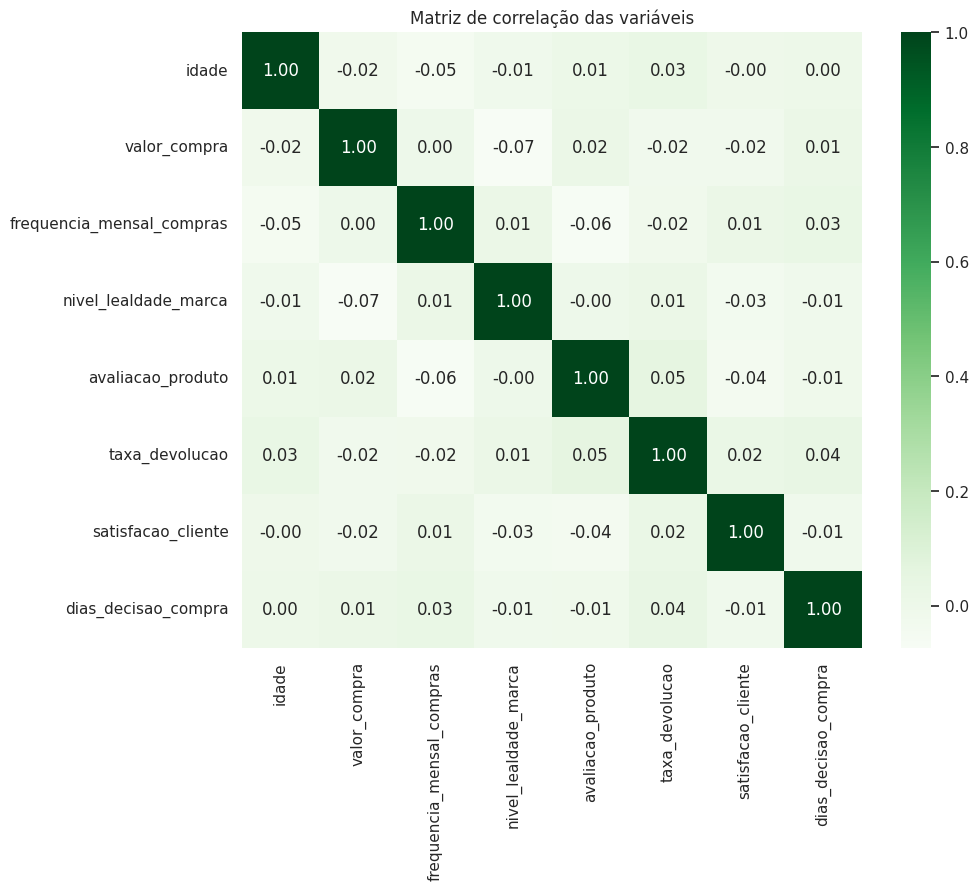

In [815]:
# matriz de correlação

colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[colunas_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap='Greens',
    fmt=".2f"
)
plt.title('Matriz de correlação das variáveis')
plt.show()

In [816]:
# correlação em relação a target
corr_target = df.corr(numeric_only=True)['valor_compra'].sort_values(ascending=False)
corr_target

,valor_compra
valor_compra,1.000000
avaliacao_produto,0.015984
dias_decisao_compra,0.014690
frequencia_mensal_compras,0.000930
idade,-0.016300
taxa_devolucao,-0.020808
satisfacao_cliente,-0.022467
nivel_lealdade_marca,-0.074222


Nenhuma variável tem relação forte com o valor de compra
A análise de correlação entre as variáveis numéricas e o target (valor_compra) não indicou relações lineares fortes. Portanto, nenhuma variável foi removida nesta etapa com base em correlação.

In [817]:
# colunas analisadas
colunas_modelo = [
    'idade',
    'genero',
    'categoria_compra',
    'canal_compra',
    'sensibilidade_compra_promocao',
    'influencia_redes_sociais',
    'motivacao_compra',
    'dispositivo_compra',
    'grupo_categoria_compra',
    'faixa_etaria',
    'genero_agrupado',
    'canal_agrupado'
]

## Modelagem

### Separação dos dados

In [818]:
# separa em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#### Criação de Modelos

In [819]:
# cria modelo
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

#### Avaliação dos Modelos

In [820]:
# avaliação de Modelo
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 118.48445950000001
RMSE: 136.54294110374494
R²: -0.07066006979619366


## Conclusão e Insights

Com o R² negativo, observa-se que o modelo não conseguiu aprender padrões relevantes para prever o valor_compra, apresentando desempenho inferior a uma previsão baseada na média.

Esse resultado já era esperado considerando que as variáveis apresentaram correlações muito baixas com o target, indicando ausência de relações lineares fortes entre as features e a variável alvo.

Além disso, a baixa capacidade preditiva sugere que os dados disponíveis, possivelmente por serem sintéticos, não capturam relações suficientemente estruturadas ou informativas para o problema proposto.

